In [4]:
#07-May-26, Noor Natour
#Import computational functions used in the analysis.
from computational_routines import *
import matplotlib
import scipy
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gmean
import sys
from scipy.io import loadmat

In [2]:
#Print Python and package versions used in the analysis.

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SciPy:", scipy.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
SciPy: 1.16.3


In [5]:
# Load the MATLAB matrix
data = loadmat("sig_all.mat")
sig_all = data["sig_all"].astype(int)


# Names of all six columns
all_columns = ["Cues","Position","Kinematics","Accuracy","Previous reward","Reward"]

# The five variables included in the encoding analysis
analysis_columns = ["Cues","Position","Kinematics","Accuracy","Previous reward"]

# Convert the full matrix to a DataFrame
df_sig_all = pd.DataFrame(sig_all, columns=all_columns)
df_all = df_sig_all[analysis_columns].copy()
n_neurons_all = len(df_all)
variable_counts_all = df_all.sum()
df = pd.DataFrame({"variable": analysis_columns,"count": variable_counts_all.values,"total": n_neurons_all})
variable_probs = {row["variable"]: row["count"] / row["total"] for _, row in df.iterrows()}

# Reward-responsive population, select rows where Reward equals 1
df_reward = df_sig_all.loc[df_sig_all["Reward"] == 1, analysis_columns].copy()
n_neurons_reward = len(df_reward)
variable_counts_reward = df_reward.sum()

df_reward_variables = pd.DataFrame({"variable": analysis_columns,"count": variable_counts_reward.values,"total": n_neurons_reward})

variable_probs_reward = {row["variable"]: row["count"] / row["total"]for _, row in df_reward_variables.iterrows()}

print(df)
print("\nFull population:", n_neurons_all)
print("Reward-responsive population:", n_neurons_reward)

# Number of variables encoded by each neuron
variables_per_neuron_all = df_all.sum(axis=1)
variables_per_neuron_reward = df_reward.sum(axis=1)

# Distribution of neurons encoding exactly 0–5 variables
distribution_all = (variables_per_neuron_all.value_counts().reindex(range(6), fill_value=0).sort_index())

distribution_reward = (variables_per_neuron_reward.value_counts().reindex(range(6), fill_value=0).sort_index())

df_obs = pd.DataFrame({"k": range(6),"all_neurons": distribution_all.values,"reward_neurons": distribution_reward.values})

          variable  count  total
0             Cues     77    303
1         Position     91    303
2       Kinematics    137    303
3         Accuracy     69    303
4  Previous reward     95    303

Full population: 303
Reward-responsive population: 232


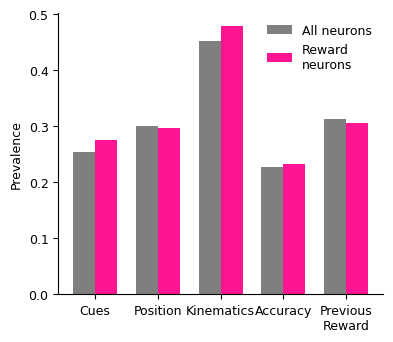

In [31]:
#09-May-26
#plot variable prevalence (Fig. 1a)

variable_names=[name.title().replace(" ", "\n") for name in df["variable"]]
prevalence=(df["count"]/df['total']).tolist()

prevalence_reward=(df_reward_variables["count"] / df_reward_variables["total"]).tolist()
plt.figure(figsize=(4, 3.5))
plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.bar(x - width / 2, prevalence, width=width, color='tab:gray', label="All neurons")
plt.bar(x + width / 2, prevalence_reward, width=width,color='deeppink', label="Reward\nneurons")
plt.ylabel("Prevalence")
plt.xticks(x, variable_names)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.legend(frameon=False)
plt.savefig("variable_prevalence.pdf", bbox_inches='tight')
plt.show()

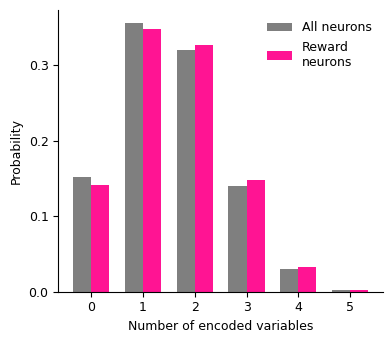

In [32]:
#09-May-26
#plot expected probability distribution (Fig. 1b)

k_probability_values=list(range(len(variable_probs)+1))
probability_results=[]
probability_results_reward=[]

for k in k_probability_values:
    p_k, expected=probability_k_variables(k, variable_probs, n_neurons=n_neurons_all)
    probability_results.append({"k":k, 'probabilities':p_k, 'expected':expected})
    p_k_reward, expected_reward = probability_k_variables(k, variable_probs_reward, n_neurons=n_neurons_reward)
    probability_results_reward.append({"k": k, "probabilities": p_k_reward, "expected": expected_reward})

df_expected=pd.DataFrame(probability_results)
df_expected_reward=pd.DataFrame(probability_results_reward)

plt.figure(figsize=(4,3.5))

plt.bar(df_expected["k"] - width/2, df_expected["probabilities"],color='tab:gray', width=width, label="All neurons")
plt.bar(df_expected_reward["k"] + width/2, df_expected_reward["probabilities"], color='deeppink', width=width, label="Reward\nneurons")

plt.rcParams.update({'font.size': 9, 'font.family': 'DejaVu Sans'})
plt.xlabel("Number of encoded variables")
plt.ylabel("Probability")
plt.xticks(k_probability_values)
plt.yticks(np.arange(0, 0.37, 0.1))
plt.legend(frameon=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("num_encoded_var.pdf", bbox_inches='tight')
plt.show()

In [33]:
#07-May-26
#Compare observed and expected distributions for all neuron (Fig. 2b)
#Calculate the observed and expected number of neurons encoding 0–5 variables for the full cue-period neuron population.
#Calculate binomial right-tail probabilities, the geometric mean of the p-values, and a two-sample Kolmogorov-Smirnov test.
#Calls: probability_k_variables(), binom_right_tail(), enumerate_discrete()
observed_counts_all=dict(zip(df_obs["k"], df_obs["all_neurons"]))
observed_values_all=[]
expected_values_all=[]
p_values_all=[]

print(f"{'k':<3} {'observed':<10} {'expected':<10} {'p(x>=obs)'}")

for _, row in df_expected.iterrows():
    k=int(row["k"])
    p=row["probabilities"]
    expected=row["expected"]
    observed=observed_counts_all[k]
    tail_prob=binom_right_tail(n_neurons_all, observed, p)

    observed_values_all.append(observed)
    expected_values_all.append(expected)
    p_values_all.append(tail_prob)

    print(f"{k:<3} {observed:<10} {expected:<10.2f} {tail_prob:<12.4f}")

#10-May-26
#Calculate the Kolmogorov-Smirnov test
ks_statistic_all, ks_p_value_all=ks_discrete_test(observed_counts_all.keys(), observed_counts_all.values(), expected_values_all)

#15-May-26
#Calculate the geometric mean
geo_mean_all = gmean(p_values_all)

print(f"\nGeometric mean: {geo_mean_all:.4f}")

print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic_all:.4f}")
print(f"p-value = {ks_p_value_all:.4f}")

k   observed   expected   p(x>=obs)
0   47         45.93      0.4561      
1   104        107.78     0.6948      
2   103        97.15      0.2538      
3   40         42.39      0.6785      
4   6          9.00       0.8880      
5   3          0.75       0.0398      

Geometric mean: 0.3529

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.0099
p-value = 1.0000


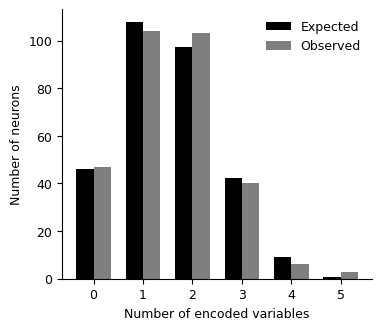

In [12]:
#07-May-26
#plot observed and expected distribution for all neurons (Fig. 2a)
k_values=list(observed_counts_all.keys())
observed_all_neurons=list(observed_counts_all.values())
expected_all_neurons=list(df_expected['expected'])

x=np.arange(len(k_values))
width=0.35
plt.rcParams.update({'font.size': 9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4, 3.5))
plt.bar(x-width/2, expected_all_neurons, width, color='k', label="Expected")
plt.bar(x+width/2, observed_all_neurons, width, color='tab:gray', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(x, k_values)
plt.legend(frameon=False)
plt.savefig("all_neurons_Ex_Ob.pdf", bbox_inches='tight')
plt.show()


In [14]:
#07-May-26
#Compare observed and expected distributions for reward-responsive neurons (table 3b)
#Calculate the observed and expected number of reward-responsive neurons encoding 0–5 variables.
#Calculate binomial right-tail probabilities, the geometric mean of the p-values, and a two-sample Kolmogorov-Smirnov test.
#Calls: probability_k_variables(), binom_right_tail(), enumerate_discrete()
observed_counts_reward=dict(zip(df_obs['k'], df_obs["reward_neurons"]))
n_neurons_reward=sum(observed_counts_reward.values())

observed_values_reward=[]
expected_values_reward=[]
p_values_reward=[]
rows_reward=[]

for k in observed_counts_reward:
    p, expected= probability_k_variables(k, variable_probs_reward, n_neurons=n_neurons_reward)
    observed=observed_counts_reward[k]

    tail_prob=binom_right_tail(n_neurons_reward, observed, p)

    rows_reward.append({"k": k, "Observed": observed, "Expected": round(expected, 2), "p(x>=obs)": round(tail_prob, 4)})
    observed_values_reward.append(observed)
    expected_values_reward.append(expected)
    p_values_reward.append(tail_prob)

df_reward=pd.DataFrame(rows_reward)
print(df_reward.to_string(index=False))


#10-May-26
#Calculate the Kolmogorov-Smirnov test
ks_statistic_reward, ks_p_value_reward=ks_discrete_test(observed_counts_reward.keys(), observed_counts_reward.values(), expected_values_reward)

#15-May-26
#Calculate the geometric mean
geo_mean_reward=gmean(p_values_reward)
print(f"Geometric mean: {geo_mean_reward:.4f}")

print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic_reward:.4f}")
print(f"p-value = {ks_p_value_reward:.4f}")

 k  Observed  Expected  p(x>=obs)
 0        28     32.78     0.8402
 1        87     80.83     0.2165
 2        78     75.86     0.4062
 3        32     34.33     0.6943
 4         5      7.55     0.8758
 5         2      0.65     0.1380
Geometric mean: 0.4286

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.0209
p-value = 1.0000


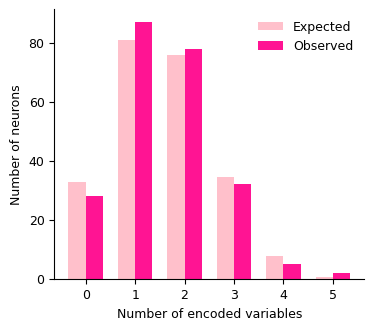

In [15]:
#07-May-26
#Plot observed and expected distribution for reward-responsive neurons (Fig. 3a)

k_values_reward=df_reward['k'].values
observed_reward_response=df_reward['Observed']
expected_reward_response=df_reward['Expected']
x_reward=np.arange(len(k_values_reward))

plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4,3.5))
plt.bar(x_reward-width/2, expected_reward_response, width, color='pink', label="Expected")
plt.bar(x_reward+width/2, observed_reward_response, width, color='deeppink', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.xticks(x_reward, k_values_reward)
plt.yticks(np.arange(0, max(observed_reward_response), 20))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(frameon=False)
plt.savefig("reward_responsive_Ex_Ob.pdf", bbox_inches='tight')
plt.show()